# High-dimensional Gaussian simulation study

Demonstrates `CUSUM` (aggregation="max-sum") on $p = 1000$-dimensional Gaussian data.
Both FAP-calibrated ($\alpha = 5\%$, $N = 1000$) and ARL-calibrated
($\mathrm{ARL}_0 = 1000$) detectors are compared across three sparsity levels
($s = 1, 10, 100$) as signal strength $\|\mu\|_2$ varies.

### For exact reproducability please do not change the variabe n_jobs

In [ ]:
import pathlib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import gridcp as gc
from gridcp.scores import CUSUM

plt.style.use("seaborn-v0_8-whitegrid")

# ── Configuration ─────────────────────────────────────────────────────────────
P = 1000  # dimension
N = 1000  # stream length
TAU = N // 2  # changepoint location (0-based, first post-change index)
FAP = 0.05  # target false alarm probability
ARL_TARGET = N  # target average run length

SPARSITY_LEVELS = [1, 10, P]  # number of active coordinates
PHI_VALUES = np.linspace(0, 4.0, 17)  # signal strengths ||mu||_2

N_PATHS_CALIBRATE = 1000
N_PATHS_EVAL = 1000
N_JOBS = 18  # for exact reproducibility, do not change this!!
RNG_SEED = 1234

FIGURE_DIR = pathlib.Path(".")  # figures saved alongside this notebook


# ── Samplers ──────────────────────────────────────────────────────────────────
def gaussian_sampler(rng, mean):
    return rng.normal(size=len(mean), loc=mean, scale=1.0)


NULL_MEAN = np.zeros(P)

# ── Calibration ───────────────────────────────────────────────────────────────
# FAP-calibrated: time-dependent penalty (enable_penalty=True)
score_fap = CUSUM(n_features=P, aggregation="max-sum", enable_penalty=True)
threshold_fap = gc.calibrate_threshold_false_alarm(
    score_fap,
    false_alarm_probability=FAP,
    n_paths=N_PATHS_CALIBRATE,
    stream_len=N,
    pre_sampler=gaussian_sampler,
    pre_kwargs={"mean": NULL_MEAN},
    rng=RNG_SEED,
    n_jobs=N_JOBS,
)
detector_fap = gc.GridDetector(score=score_fap, threshold=threshold_fap)
print(f"FAP threshold: {threshold_fap}")

# ARL-calibrated: stationary score required (enable_penalty=False)
score_arl = CUSUM(n_features=P, aggregation="max-sum", enable_penalty=False)
threshold_arl = gc.calibrate_threshold_arl(
    score_arl,
    target_arl=ARL_TARGET,
    n_paths=N_PATHS_CALIBRATE,
    pre_sampler=gaussian_sampler,
    pre_kwargs={"mean": NULL_MEAN},
    rng=RNG_SEED,
    n_jobs=N_JOBS,
)
detector_arl = gc.GridDetector(score=score_arl, threshold=threshold_arl)
print(f"ARL threshold: {threshold_arl}")


# ── Helpers ───────────────────────────────────────────────────────────────────
def make_mu(phi, s):
    """Mean vector with ||mu||_2 = phi concentrated in the first s coordinates."""
    mu = np.zeros(P)
    mu[:s] = phi / np.sqrt(s)
    return mu


def compute_mean_delay(alarm_times, tau, stream_len):
    """Mean delay. Paths alarming before tau are capped at stream_len - tau."""
    delays = alarm_times - tau
    return float(np.mean(delays[delays >= 0]))


# ── Simulation loop ───────────────────────────────────────────────────────────
detectors = {"FAP": detector_fap, "ARL": detector_arl}
records = []

for cal_name, detector in detectors.items():
    for s in SPARSITY_LEVELS:
        for phi in PHI_VALUES:
            mu = make_mu(phi, s)
            alarm_times = gc.mc_alarm_times(
                detector,
                n_paths=N_PATHS_EVAL,
                stream_len=N,
                pre_sampler=gaussian_sampler,
                pre_kwargs={"mean": NULL_MEAN},
                post_sampler=gaussian_sampler,
                post_kwargs={"mean": mu},
                changepoint=TAU,
                rng=RNG_SEED + 1,  # different RNG seed for evaluation
                n_jobs=N_JOBS,
            )
            records.append(
                {
                    "phi": phi,
                    "sparsity": s,
                    "calibration": cal_name,
                    "mean_delay": compute_mean_delay(alarm_times, TAU, N),
                }
            )

results = pd.DataFrame(records)

FAP threshold: [2.1566327  3.58699078]
ARL threshold: [ 27.79212985 177.01053048]


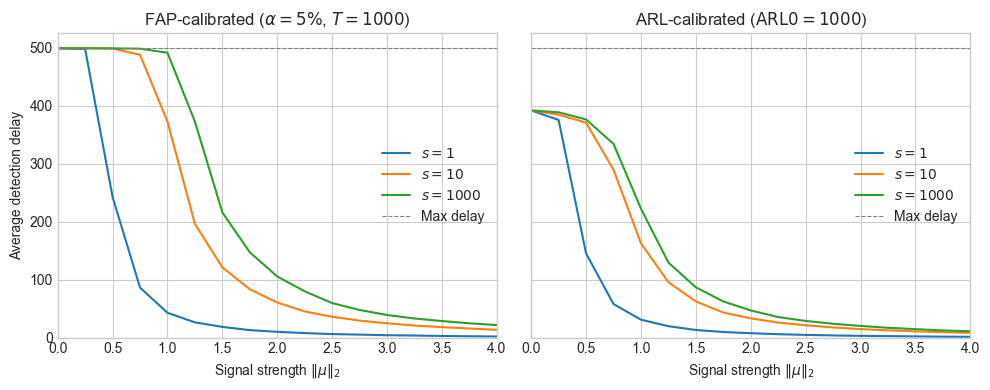

In [19]:
# ── Detection delay plot ──────────────────────────────────────────────────────
COLORS = dict(zip(SPARSITY_LEVELS, ["tab:blue", "tab:orange", "tab:green"]))
LABELS = {s: rf"$s = {s}$" for s in SPARSITY_LEVELS}
TITLES = {
    "FAP": rf"FAP-calibrated ($\alpha = {int(FAP * 100)}\%$, $T = {N}$)",
    "ARL": rf"ARL-calibrated ($\mathrm{{ARL}}0 = {ARL_TARGET}$)",
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, cal_name in zip(axes, ["FAP", "ARL"]):
    sub = results[results["calibration"] == cal_name]
    for s in SPARSITY_LEVELS:
        row = sub[sub["sparsity"] == s].sort_values("phi")
        ax.plot(row["phi"], row["mean_delay"], color=COLORS[s], label=LABELS[s])
    ax.axhline(N - TAU, color="gray", linestyle="--", linewidth=0.8, label="Max delay")
    ax.set_xlabel(r"Signal strength $\|\mu\|_2$")
    ax.set_title(TITLES[cal_name])
    ax.legend()
    ax.set_xlim(0, PHI_VALUES[-1])
    ax.set_ylim(0, N - TAU + 25)

axes[0].set_ylabel("Average detection delay")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "highd_mean_delay.pdf", bbox_inches="tight")
plt.show()

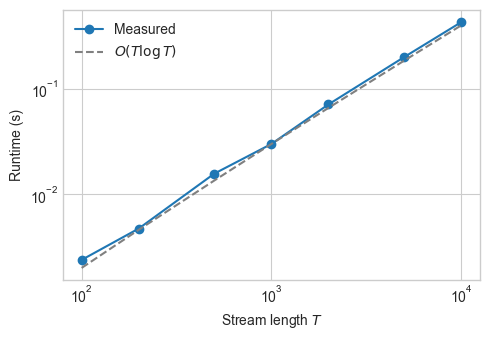

In [23]:
# ── Runtime benchmark (post-JIT) ──────────────────────────────────────────────
# Warmup: trigger Numba JIT compilation before timing
_warmup_state = detector_fap.init_state()
_warmup_rng = np.random.default_rng(0)
for _ in range(100):
    _warmup_state, _ = detector_fap.update(
        _warmup_state, _warmup_rng.standard_normal(P)
    )

N_RT_REPS = 10
N_RT_VALUES = [100, 200, 500, 1_000, 2_000, 5_000, 10_000]
_rt_rng = np.random.default_rng(0)
runtime_records = []

for n in N_RT_VALUES:
    data = _rt_rng.standard_normal((n, P))
    times = []
    for _ in range(N_RT_REPS):
        state = detector_fap.init_state()
        t0 = time.perf_counter()
        for x in data:
            state, _ = detector_fap.update(state, x)
        times.append(time.perf_counter() - t0)
    runtime_records.append({"N": n, "time_s": np.median(times)})

runtime = pd.DataFrame(runtime_records)

# ── Runtime plot ──────────────────────────────────────────────────────────────
n_arr = np.array(N_RT_VALUES, dtype=float)
t_ref = runtime.loc[runtime["N"] == 1000, "time_s"].values[0]
ref_line = t_ref * (n_arr * np.log(n_arr)) / (1000 * np.log(1000))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(runtime["N"], runtime["time_s"], "o-", color="tab:blue", label="Measured")
ax.plot(n_arr, ref_line, "--", color="gray", label=r"$O(T \log T)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stream length $T$")
ax.set_ylabel("Runtime (s)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "highd_runtime.pdf", bbox_inches="tight")
plt.show()

In [24]:
runtime_10k = runtime.loc[runtime["N"] == 10_000, "time_s"].values[0]
print(f"Time to process the first 10 000 samples: {runtime_10k:.3f} seconds")

Time to process the first 10 000 samples: 0.430 seconds
